# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

## Постановка задачи

Теперь настало время самостоятельной работы. В рамках самостоятельной работы вам предстоит решить задачу прогнозирования оттока клиентов банка. 

> **Примечание.** Вы уже знакомились с этой задачей в модуле по визуализации («PYTHON-13. Визуализация данных») и провели небольшое исследование данных. Вы можете использовать результаты своего исследования для построения модели машинного обучения.

Напомним контекст задачи:

> Некоторый банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдёт ли клиент в ближайшее время. 

Итак, ранее вы провели небольшой разведывательный анализ, познакомились с данными и выявили, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов. Вы отлично справились с первой задачей, и теперь представители банка предлагают вам построить саму модель машинного обучения, которая будет прогнозировать отток клиентов. 

**Ваша задача** - построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

Разделим эту задачу на две части:
* В первой части мы подготовим данные для моделирования и построим простейшую модель логистической регрессии, оценим её качество и проанализируем результаты её работы.

* Во второй части мы займёмся построением моделей дерева решений и случайного леса, сравним их результаты с результатами, полученными на первом этапе, и сделаем финальный вывод.


Для начала импортируем библиотеки, которые нам понадобятся:

In [10]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
%matplotlib inline

Итак, прочитаем нашу таблицу:

In [11]:
churn_data = pd.read_csv('churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Практика: логистическая регрессия

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9:

### Задание 5.0 (не оценивается)

Для полноты задачи проведите небольшой разведывательный анализ данных. Постройте графики распределения целевого признака, диаграммы и графики, показывающие взаимосвязь между исходными признаками и целевым признаком, а также другие диаграммы, иллюстрирующие предоставленные данные. 

**Совет:** воспользуйтесь кодом, который вы писали, выполняя задания в модуле «PYTHON-13. Визуализация данных».

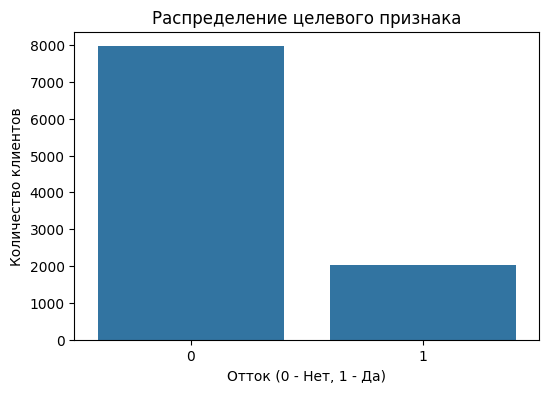

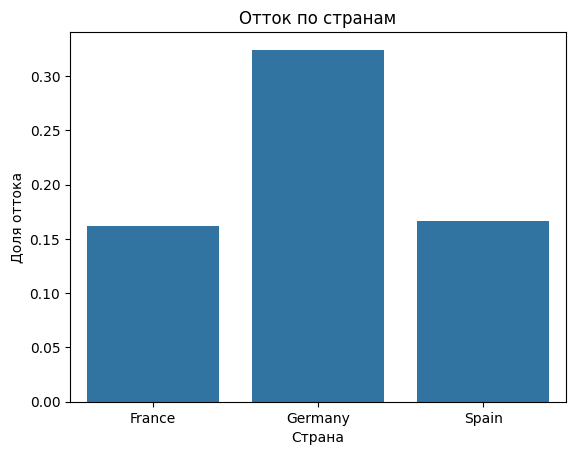

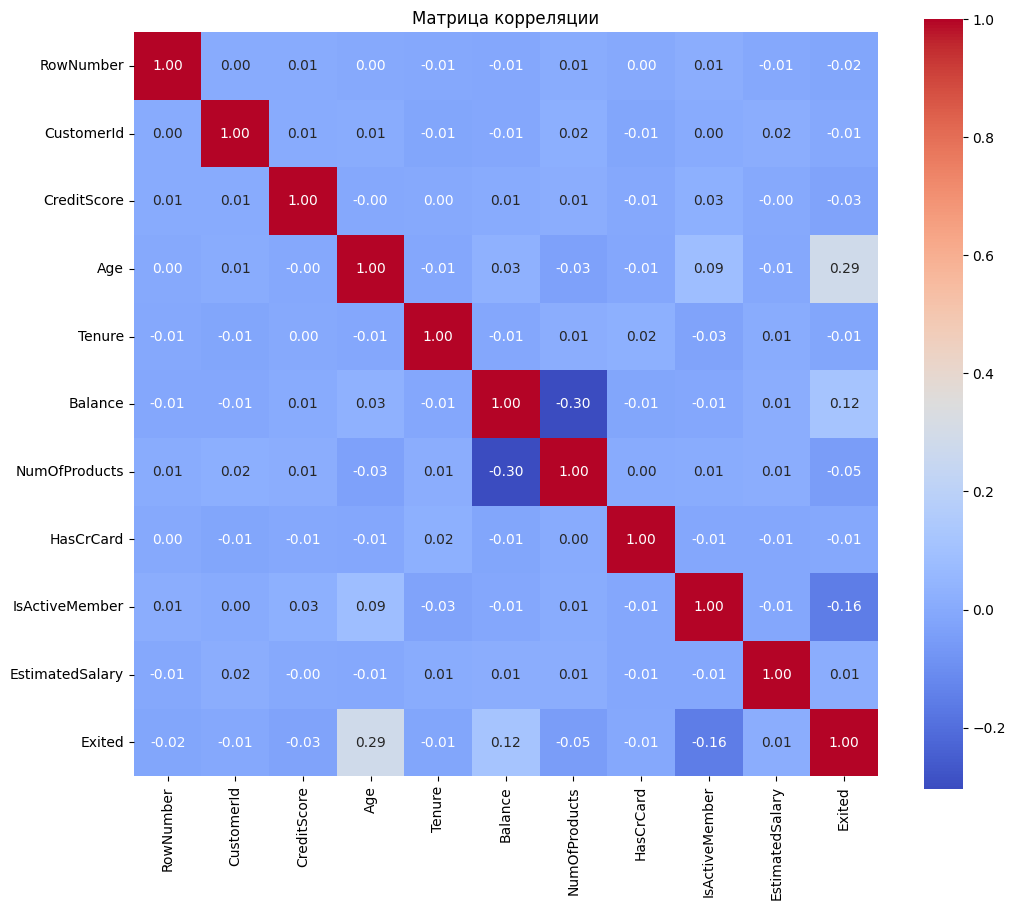

In [12]:
# Ваш код здесь

# Распределение целевого признака
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Exited', data=churn_data)
plt.title('Распределение целевого признака')
plt.xlabel('Отток (0 - Нет, 1 - Да)')
plt.ylabel('Количество клиентов')
plt.show()

# Отток по странам
country_churn = churn_data.groupby('Geography')['Exited'].mean().reset_index()
sns.barplot(x='Geography', y='Exited', data=country_churn)
plt.title('Отток по странам')
plt.xlabel('Страна')
plt.ylabel('Доля оттока')
plt.show()

plt.figure(figsize=(12, 10))
numeric_df = churn_data.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Матрица корреляции')
plt.show()


В модуле по визуализации мы выяснили, что отток в Германии, Франции и Испании имеет различные показатели. Исследователи, которые уже работали с этим датасетом, пришли к выводу, что наилучшее решение при работе с этими данными — строить модели индивидуально для каждой страны. Мы будем прогнозировать отток в немецком филиале банка. Давайте выделим только данные, относящиеся к Германии:

In [13]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.

In [14]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Female,29,4,115046.74,4,1,0,119346.88,1
15,616,Male,45,3,143129.41,2,0,1,64327.26,0
16,653,Male,58,1,132602.88,1,1,0,5097.67,1
26,756,Male,36,2,136815.64,1,1,1,170041.95,0
28,574,Female,43,3,141349.43,1,1,1,100187.43,0


Проверим, что в наших данных нет пропусков:

In [15]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [16]:
churn_data[churn_data.duplicated()].sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
dtype: object

### Задание 5.1 (1 балл)

Давайте сделаем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создайте следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Затем перекодируйте оставшиеся текстовые категориальные признаки в числовые бинарные столбцы.

Выведите основные статистические характеристики полученных признаков.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания указанных в задании признаков;
    * приведён код для кодирования категориальных признаков в числовые бинарные столбцы;
    * приведён код для расчёта основных статистических характеристик полученных признаков.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [17]:
# Ваш код здесь

# Копируем данные, чтобы не изменять исходный DataFrame
churn_data_ger = churn_data.copy()

# Создание новых признаков
# Признак: отношение баланса к заработной плате
# Обрабатываем случай, когда EstimatedSalary = 0
churn_data_ger['BalanceSalaryRatio'] = np.where(
    churn_data_ger['EstimatedSalary'] > 0,  # условие: зарплата больше 0
    churn_data_ger['Balance'] / churn_data_ger['EstimatedSalary'],
    0 
)

# Признак: отношение времени пользования услугами к возрасту
# Обрабатываем случай, когда Age = 0 
churn_data_ger['TenureByAge'] = np.where(
    churn_data_ger['Age'] > 0,
    churn_data_ger['Tenure'] / churn_data_ger['Age'],
    0
)

# Признак: отношение кредитного рейтинга к возрасту
# Обрабатываем случай, когда Age = 0
churn_data_ger['CreditScoreGivenAge'] = np.where(
    churn_data_ger['Age'] > 0,
    churn_data_ger['CreditScore'] / churn_data_ger['Age'],
    0
)

# Кодирование категориальных признаков
churn_data_ger['Gender'] = churn_data_ger['Gender'].map({'Male': 0, 'Female': 1})

# Проверяем, что все признаки стали числовыми
print("Типы данных после кодирования:")
print(churn_data_ger.dtypes)
print("\n")

# Выводим первые 5 строк с новыми признаками
print("Первые 5 строк данных после feature engineering:")
display(churn_data_ger.head())
print("\n")

# Выводим статистические характеристики новых признаков
print("Статистические характеристики новых признаков:")
print(churn_data_ger[['BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']].describe())


Типы данных после кодирования:
CreditScore              int64
Gender                   int64
Age                      int64
Tenure                   int64
Balance                float64
NumOfProducts            int64
HasCrCard                int64
IsActiveMember           int64
EstimatedSalary        float64
Exited                   int64
BalanceSalaryRatio     float64
TenureByAge            float64
CreditScoreGivenAge    float64
dtype: object


Первые 5 строк данных после feature engineering:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
7,376,1,29,4,115046.74,4,1,0,119346.88,1,0.963969,0.137931,12.965517
15,616,0,45,3,143129.41,2,0,1,64327.26,0,2.225020,0.066667,13.688889
16,653,0,58,1,132602.88,1,1,0,5097.67,1,26.012449,0.017241,11.258621
26,756,0,36,2,136815.64,1,1,1,170041.95,0,0.804599,0.055556,21.000000
28,574,1,43,3,141349.43,1,1,1,100187.43,0,1.410850,0.069767,13.348837




Статистические характеристики новых признаков:
       BalanceSalaryRatio  TenureByAge  CreditScoreGivenAge
count         2509.000000  2509.000000          2509.000000
mean             9.024870     0.134303            17.526487
std            214.286020     0.087680             5.349558
min              0.192582     0.000000             6.112676
25%              0.783284     0.060606            13.686275
50%              1.197220     0.125000            16.857143
75%              2.400083     0.200000            20.852941
max          10614.655440     0.500000            46.388889


Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [18]:
X = churn_data_ger.drop("Exited", axis=1)
y = churn_data_ger["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:

In [19]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

То есть нам нужно сделать так, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [20]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [21]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

### Задание 5.2 (1 балл)

Позаботьтесь о масштабировании признаков. Проведите нормализацию/стандартизацию матрицы наблюдений `X` с помощью `MinMaxScaler`/`RobustScaler` или `StandardScaler`. Выберите метод самостоятельно.

Обучите один из предложенных скейлеров на тренировочной выборке (вычислите параметры трансформации) и примените трансформацию данных к тренировочной и тестовой выборкам.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания одного из вариантов скейлеров для масштабирования данных;
    * приведён код для расчёта параметров трансформации (обучение скейлера) на тренировочной выборке;
    * приведён код для трансформации тренировочных и тестовых данных (признаков) в соответствии с вычисленными параметрами.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [22]:
# Ваш код здесь

# Используем StandardScaler (стандартизация)
# Создаем и обучаем скейлер
scaler = preprocessing.StandardScaler()

# Обучаем скейлер только на тренировочной выборке
scaler.fit(X_train)
# Применяем трансформацию к данным
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Теперь переходим к моделированию.

### Задание 5.3 (1 балл)

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор. 


> Укажите название метрики и обоснования своего выбора здесь

Метрика: F1-Мера 

Обоснование выбора:

В данной задаче наблюдается дисбаланс классов: лояльных клиентов ~68%, ушедших ~32%. При таком дисбалансе метрика Accuracy будет неинформативной — модель, предсказывающая всех как "лояльных", получит высокую точность, но не найдет ни одного ушедшего клиента.

Precision — показывает, какая доля клиентов, определенных моделью как уходящие, действительно уходит. Это важно для минимизации ложноположительных срабатываний, чтобы не тратить ограниченные ресурсы колл-центра на клиентов, которые на самом деле не собираются уходить.

Recall — показывает, какую долю от всех реально ушедших клиентов модель смогла обнаружить. Это важно для минимизации ложноотрицательных срабатываний, чтобы не упустить клиентов, которые действительно собираются уйти.

F1-Мера позволяет найти баланс между этими двумя показателями(как раз используется в задачах, где необходимо балансировать между precision и recall.), что идеально соответствует бизнес-задаче: с одной стороны, ресурсы ограничены (важна метрика Precision), с другой — нужно сохранить как можно больше клиентов (важна метрика Recall).

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * выбрана верная метрика;
    * приведено развернутое обоснование выбора метрики, и приведенные рассуждения являются верными;

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

> Ваши рассуждения и ответ — *здесь*.

F1-Мера является оптимальной метрикой, так как учитывает дисбаланс классов, находит баланс между минимизацией ложных срабатываний и пропуском уходящих клиентов и соответствует бизнес-ограничениям.

### Задание 5.4 (2 балла)

Обучите модель логистической регрессии (`Logistic Regression`) на тренировочных данных. Позаботьтесь о воспроизводимости результата, установив конкретное значение параметра `random_state` (например, число 42).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель логистической регрессии, решающая поставленную задачу;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [30]:
# Ваш код здесь

# Создание и обучение модели логистической регрессии
logreg = linear_model.LogisticRegression(
    random_state=42,  
    max_iter=1000, 
)

# Обучаем модель на масштабированных данных
logreg.fit(X_train_scaled, y_train)

# Предсказание класса
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

# Расчет F1-Меры (выбранная метрика)
f1_train = metrics.f1_score(y_train, y_train_pred)
f1_test = metrics.f1_score(y_test, y_test_pred)

print(f"F1-Мера на обучающей выборке: {f1_train:.4f}")
print(f"F1-Мера на тестовой выборке:  {f1_test:.4f}")

F1-Мера на обучающей выборке: 0.5121
F1-Мера на тестовой выборке:  0.4943


> Ваши выводы и рассуждения — *здесь*.

F1-мера на обучающей выборке: 0.51

F1-мера на тестовой выборке: 0.49

Модель является недообученной, так как значение F1-меры на тестовой выборке составляет 0.49, что ниже порога 0.5. Согласно условию задачи, модель считается недообученной, если целевая метрика на тестовой выборке меньше 0.5.

### Задание 5.5 (2 балла)

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> **Примечание.** Обратите внимание, что для генерации полиномов необходимо использовать масштабированные данные.

Обучите модель логистической регрессии на полиномиальных признаках (`Logistic Regression`). Позаботьтесь о воспроизводимости результат, установив конкретное значение параметра `random_state` (например, число 42).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравните результат с полученным ранее. Удалось ли вам улучшить качество вашей модели?

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * сгенерированы полиномиальные признаки третьей степени;
    * построена модель логистической регрессии, решающая поставленную задачу на основе сгенерированных признаков;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [29]:
# Ваш код здесь

from sklearn.preprocessing import PolynomialFeatures

# Создание полиномиальных признаков 3-й степени
poly = PolynomialFeatures(degree=3, include_bias=False)

# Генерация полиномов на масштабированных данных
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Обучение модели логистической регрессии на полиномиальных признаках
logreg_poly = linear_model.LogisticRegression(
    random_state=42,
    max_iter=5000, # увеличиваем, так как признаков стало больше
)

logreg_poly.fit(X_train_poly, y_train)

# Предсказание класса
y_train_pred_poly = logreg_poly.predict(X_train_poly)
y_test_pred_poly = logreg_poly.predict(X_test_poly)

# Расчет F1-Меры
f1_train_poly = metrics.f1_score(y_train, y_train_pred_poly)
f1_test_poly = metrics.f1_score(y_test, y_test_pred_poly)
print(f"F1-Мера на обучающей выборке: {f1_train_poly:.4f}")
print(f"F1-Мера на тестовой выборке:  {f1_test_poly:.4f}")

F1-Мера на обучающей выборке: 0.7730
F1-Мера на тестовой выборке:  0.6423


> Ваши выводы и рассуждения — *здесь*

F1-мера на обучающей выборке: 0.77

F1-мера на тестовой выборке: 0.64

Базовая модель F1 (тестовая выборка): 0.49

Полиномиальная модель F1 (тестовая выборка): 0.64

Улучшение: +0.15 => Полиномиальные признаки значительно улучшили качество модели.

### Задание 5.6. (2 балла)


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. В качестве модели используйте логистическую регрессию, обученную на полиномиальных признаках. 

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список.

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для построения графика зависимости значения выбранной метрики от порога вероятности;
    * найден оптимальный порог вероятности, на котором достигается наибольшее значение выбранной метрики на тестовой выборке;
    * на основе найденного порога вероятности построено предсказание модели для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

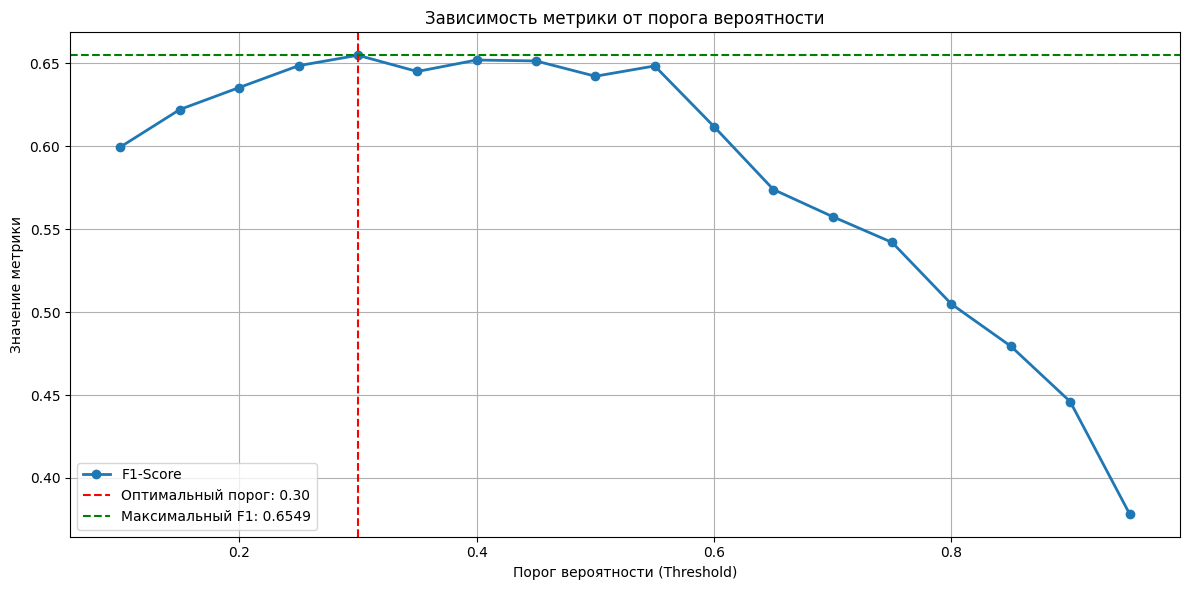

Оптимальный порог вероятности: 0.30
F1-Мера на обучающей выборке: 0.7763
F1-Мера на тестовой выборке:  0.6549


In [26]:
# Ваш код здесь

# Предсказание вероятностей на тестовой выборке
y_test_proba = logreg_poly.predict_proba(X_test_poly)[:, 1]

# Инициализация списка для метрики
thresholds = np.arange(0.1, 1, 0.05)
f1_scores = []

# Цикл по порогам для расчета метрик
for threshold in thresholds:
    # Делаем предсказание на основе порога
    y_test_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    # Рассчитываем метрику
    f1 = metrics.f1_score(y_test, y_test_pred_threshold)
    
    # Добавляем результаты в список
    f1_scores.append(f1)
    
# Построение графика зависимости метрики от порога
plt.figure(figsize=(12, 6))

plt.plot(thresholds, f1_scores, marker='o', label='F1-Score', linewidth=2)

# Находим и отмечаем точку с максимальным F1
max_f1 = max(f1_scores)
optimal_threshold = thresholds[np.argmax(f1_scores)]

plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Оптимальный порог: {optimal_threshold:.2f}')
plt.axhline(y=max_f1, color='green', linestyle='--', 
            label=f'Максимальный F1: {max_f1:.4f}')

plt.xlabel('Порог вероятности (Threshold)')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрики от порога вероятности')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Оптимальный порог вероятности: {optimal_threshold:.2f}")

# Предсказание с оптимальным порогом
y_test_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)
y_train_proba = logreg_poly.predict_proba(X_train_poly)[:, 1]
y_train_pred_optimal = (y_train_proba >= optimal_threshold).astype(int)

# Расчет метрик с оптимальным порогом
f1_train_optimal = metrics.f1_score(y_train, y_train_pred_optimal)
f1_test_optimal = metrics.f1_score(y_test, y_test_pred_optimal)

print(f"F1-Мера на обучающей выборке: {f1_train_optimal:.4f}")
print(f"F1-Мера на тестовой выборке:  {f1_test_optimal:.4f}")

## Практика: деревья решений и случайный лес

Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.


> **Примечание №1.** Для выполнения дальнейших заданий необходимо совершить уже знакомые шаги предобработки с данными об оттоке клиентов банка, а именно:
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание №2.** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [27]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Импортируем необходимые для выполнения практики модули:

In [28]:
from sklearn import tree
from sklearn import ensemble

Приступим! Выполните задания 8.1–8.4.

### Задание 8.1. (2 балла)

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с неограниченной максимальной глубиной дерева. В качестве критерия информативности используйте энтропию Шеннона, остальные параметры оставьте по умолчанию. 

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:
* Как вы считаете, является полученная модель переобученной или недообученной? Попробуйте дать обоснование, почему так происходит.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос, а также обоснование полученного результата.

- Задание выполнено верно, но не приведено обоснование полученного результата или обоснование является некорректным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [33]:
# Ваш код здесь

# Создание и обучение модели дерева решений с неограниченной глубиной
dt_unlimited = tree.DecisionTreeClassifier(
    criterion='entropy',  # энтропия Шеннона
    random_state=42,  
)

dt_unlimited.fit(X_train, y_train)

# Предсказание класса
y_train_pred_dt = dt_unlimited.predict(X_train)
y_test_pred_dt = dt_unlimited.predict(X_test)

# Расчет F1-Меры
f1_train_dt = metrics.f1_score(y_train, y_train_pred_dt)
f1_test_dt = metrics.f1_score(y_test, y_test_pred_dt)
print(f"F1-Мера на обучающей выборке: {f1_train_dt:.4f}")
print(f"F1-Мера на тестовой выборке:  {f1_test_dt:.4f}")

F1-Мера на обучающей выборке: 1.0000
F1-Мера на тестовой выборке:  0.5600


> Ваши выводы и рассуждения — *здесь*

F1-Мера на обучающей выборке: 1.00 

F1-Мера на тестовой выборке: 0.56

Модель является переобученной(Огромный разрыв между качеством на обучающей и тестовой выборках (0.44))

Это происходит потому, что дерево с неограниченной глубиной создает очень сложную структуру, модель запоминает каждый объект обучающей выборки, но на тестовых данных эти "запоминания" не работают, то есть модель не улавливает общие закономерности


### Задание 8.2. (1 балл)

Давайте «подстрижём» наше дерево. 

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с максимальной глубиной 8. В качестве критерия информативности используйте энтропию Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните результат с полученными ранее. Сделайте вывод.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [34]:
# Ваш код здесь

# Создание и обучение модели дерева решений с ограничениями
dt_limited = tree.DecisionTreeClassifier(
    criterion='entropy',      # энтропия Шеннона
    max_depth=8,              # ограничиваем глубину
    min_samples_leaf=10,      # минимальное число объектов в листе
    random_state=42           
)

dt_limited.fit(X_train, y_train)

# Предсказание меток классов
y_train_pred_dt_lim = dt_limited.predict(X_train)
y_test_pred_dt_lim = dt_limited.predict(X_test)

# Расчет F1-Меры
f1_train_dt_lim = metrics.f1_score(y_train, y_train_pred_dt_lim)
f1_test_dt_lim = metrics.f1_score(y_test, y_test_pred_dt_lim)
print(f"F1-Меры на обучающей выборке: {f1_train_dt_lim:.4f}")
print(f"F1-Меры на тестовой выборке:  {f1_test_dt_lim:.4f}")

F1-Меры на обучающей выборке: 0.7173
F1-Меры на тестовой выборке:  0.6398


> Ваши выводы и рассуждения — *здесь*

F1-Мера на обучающей выборке: 0.71 

F1-Мера на тестовой выборке: 0.63

Разрыв между обучающей и тестовой выборках значительно сократился, что означает уменьшение переобучения, также улучшилось качество на тестовой выборке(с 0,56 до 0,63), однако модель все еще может быть улучшена.

### Задание 8.3. (1 балл)

Давайте воспользуемся случайным лесом. 

Постройте случайный лес (`RandomForestClassifier`) из 500 деревьев с максимальной глубиной 8. Критерий информативности — энтропия Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните качество одного дерева решений с качеством случайного леса на тестовой выборке. Смогли ли вы улучшить метрику?


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [35]:
# Ваш код здесь

# Создание и обучение модели случайного леса
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=500,        # количество деревьев
    max_depth=8,             # максимальная глубина
    criterion='entropy',     # энтропия Шеннона
    min_samples_leaf=10,     # минимальное число объектов в листе
    random_state=42,        
)
rf_model.fit(X_train, y_train)

# Предсказание класса
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Расчет F1-Меры
f1_train_rf = metrics.f1_score(y_train, y_train_pred_rf)
f1_test_rf = metrics.f1_score(y_test, y_test_pred_rf)
print(f"F1-Мера на обучающей выборке: {f1_train_rf:.4f}")
print(f"F1-Мера на тестовой выборке:  {f1_test_rf:.4f}")

F1-Мера на обучающей выборке: 0.7351
F1-Мера на тестовой выборке:  0.6556


> Ваши выводы и рассуждения — *здесь*

F1-Мера на обучающей выборке: 0.7351

F1-Мера на тестовой выборке:  0.6556

Случайный лес немного улучшил качество на тестовой выборке по сравнению с одиночным деревом, а ансамблирование деревьев еще немного снизило переобучение и сделало модель более стабильной.

### Задание 8.4. (2 балла)

Мы на финишной прямой. 


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. **Используйте ту модель (из рассмотренных ранее), которая показала наилучшее качество на тестовой выборке.**


В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список. 

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Напишите небольшой вывод о проделанной работе, указав в нём, какая из рассмотренных нами моделей показала наилучший результат.

> **Примечание.** Помните о том, что в реальных задачах (а мы решали задачу на реальных данных) мы практически никогда не сможем получить значения метрик, близкие к 1. Если в задаче прогнозирования оттока ваша метрика превышает хотя бы значения 0.6-0.7, вашу модель уже можно считать хорошей и можно говорить о том, что она успешно справляется с задачей.

Лучшая модель: Случайный лес
F1-Мера на тестовой выборке: 0.6556


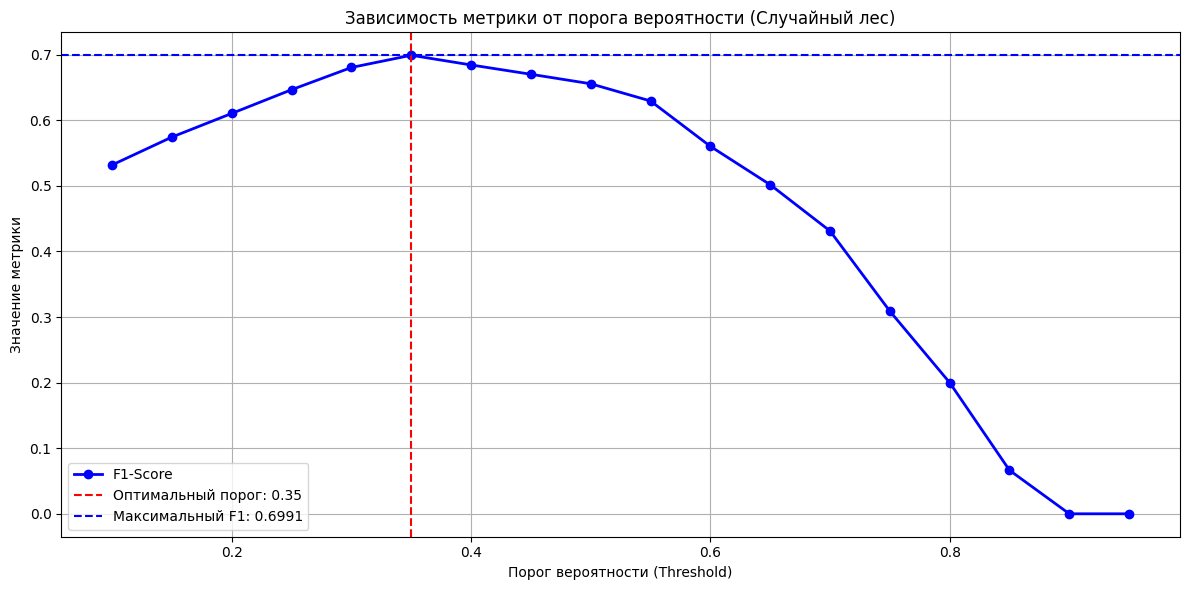

Оптимальный порог вероятности: 0.35
Максимальное значение F1-Меры: 0.6991
=== РЕЗУЛЬТАТЫ С ОПТИМАЛЬНЫМ ПОРОГОМ ===
F1-Мера на обучающей выборке: 0.7661
F1-Мера на тестовой выборке:  0.6991


In [39]:
# Ваш код здесь

# Определяем лучшую модель на основе F1-Score на тестовой выборке
models_comparison = {
    'Логистическая регрессия (полиномы)': (logreg_poly, X_test_poly, f1_test_poly),
    'Случайный лес': (rf_model, X_test, f1_test_rf),
    'Одно дерево (ограниченное)': (dt_limited, X_test, f1_test_dt_lim)
}

# Находим лучшую модель
best_model_name = max(models_comparison, key=lambda x: models_comparison[x][2])
best_model, best_X_test, best_f1 = models_comparison[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print(f"F1-Мера на тестовой выборке: {best_f1:.4f}")

# Предсказание вероятностей с помощью лучшей модели
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Подбор оптимального порога
thresholds = np.arange(0.1, 1, 0.05)
f1_scores = []

for threshold in thresholds:
    y_test_pred_threshold = (y_test_proba_rf >= threshold).astype(int)
    
    f1 = metrics.f1_score(y_test, y_test_pred_threshold)
    
    f1_scores.append(f1)

# Построение графика
plt.figure(figsize=(12, 6))

plt.plot(thresholds, f1_scores, marker='o', label='F1-Score', linewidth=2, color='blue')

# Находим оптимальный порог
max_f1 = max(f1_scores)
optimal_threshold = thresholds[np.argmax(f1_scores)]

plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Оптимальный порог: {optimal_threshold:.2f}')
plt.axhline(y=max_f1, color='blue', linestyle='--', 
            label=f'Максимальный F1: {max_f1:.4f}')

plt.xlabel('Порог вероятности (Threshold)')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрики от порога вероятности (Случайный лес)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Оптимальный порог вероятности: {optimal_threshold:.2f}")
print(f"Максимальное значение F1-Меры: {max_f1:.4f}")

# Предсказание с оптимальным порогом
y_test_pred_optimal = (y_test_proba_rf >= optimal_threshold).astype(int)
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_train_pred_optimal = (y_train_proba_rf >= optimal_threshold).astype(int)

# Расчет метрик с оптимальным порогом
f1_train_optimal = metrics.f1_score(y_train, y_train_pred_optimal)
f1_test_optimal = metrics.f1_score(y_test, y_test_pred_optimal)

print("=== РЕЗУЛЬТАТЫ С ОПТИМАЛЬНЫМ ПОРОГОМ ===")
print(f"F1-Мера на обучающей выборке: {f1_train_optimal:.4f}")
print(f"F1-Мера на тестовой выборке:  {f1_test_optimal:.4f}")

> Ваши выводы и рассуждения — *здесь*

Лучшая модель: Случайный лес

F1-Мера на тестовой выборке выросла с 0.65 до 0.69

F1-Мера > 0.69 (находится в верхней границе рекомендуемого порога 0.6-0.7), а значит модель успешно справляется с задачей прогнозирования оттока.

Оптимальный порог (0.35) ниже стандартного (0.5), то есть модель стала более чувствительной к уходящим клиентам, что позволяет находить больше клиентов, которые действительно уходят и как следствие, банк сможет эффективно использовать свои ресурсы.

### Задание 8.5. (1 балл)

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:
* добавить признаки дополнительные признаки; 
* произвести кодирование категориальных признаков;
* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;
* сгенерировать полиномиальные признаки.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * сформирован DataFrame на основе предоставленного словаря;
    * произведены преобразования данных, необходимые для работы модели;
    * предсказана вероятность оттока клиента (вероятность принадлежности к классу 1).

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [45]:
# Ваш код здесь

# Данные о Василии
vasily_data = {
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}

# Создаем DataFrame из данных Василия
vasily_df = pd.DataFrame(vasily_data)
display(vasily_df)

# Добавляем дополнительные признаки (как в задании 5.1)
# Признак: BalanceSalaryRatio
vasily_df['BalanceSalaryRatio'] = np.where(
    vasily_df['EstimatedSalary'] > 0,
    vasily_df['Balance'] / vasily_df['EstimatedSalary'],
    0
)

# Признак: TenureByAge
vasily_df['TenureByAge'] = np.where(
    vasily_df['Age'] > 0,
    vasily_df['Tenure'] / vasily_df['Age'],
    0
)

# Признак: CreditScoreGivenAge
vasily_df['CreditScoreGivenAge'] = np.where(
    vasily_df['Age'] > 0,
    vasily_df['CreditScore'] / vasily_df['Age'],
    0
)
display(vasily_df)

# Кодирование категориальных признаков
vasily_df['Gender'] = vasily_df['Gender'].map({'Male': 0, 'Female': 1})

# Выбираем лучшую модель (Случайный лес)
# Для случайного леса не нужны масштабирование и полиномы
print("Используемая модель: Случайный лес (лучшая модель)")

# Предсказываем вероятность оттока
vasily_proba = rf_model.predict_proba(vasily_df)[0, 1] 
vasily_pred = rf_model.predict(vasily_df)[0]
print(f"\nВероятность оттока для Василия: {vasily_proba:.4f} ({vasily_proba*100:.2f}%)")
print(f"\nПредсказанный класс: {'УЙДЕТ' if vasily_pred == 1 else 'ОСТАНЕТСЯ'}") 

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,601.0,Male,42.0,1.0,98495.72,1.0,1.0,0.0,40014.76


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
0,601.0,Male,42.0,1.0,98495.72,1.0,1.0,0.0,40014.76,2.461485,0.02381,14.309524


Используемая модель: Случайный лес (лучшая модель)

Вероятность оттока для Василия: 0.6229 (62.29%)

Предсказанный класс: УЙДЕТ
